# Dataset Inspection: Default of Credit Card Clients

This notebook inspects the `default_of_credit_card_clients.xls` dataset. It answers: which columns exist, which values appear in important categorical columns, how many entries are in the dataset, and how many male vs female clients there are.

## Dataset Description

There are 25 variables:

| Column | Meaning |
|---|---|
| `ID` | ID of each client |
| `LIMIT_BAL` | Amount of given credit in NT dollars, including individual and family/supplementary credit |
| `SEX` | Gender: 1 = male, 2 = female |
| `EDUCATION` | Education: 1 = graduate school, 2 = university, 3 = high school, 4 = others, 5 = unknown, 6 = unknown |
| `MARRIAGE` | Marital status: 1 = married, 2 = single, 3 = others |
| `AGE` | Age in years |
| `PAY_0` | Repayment status in September 2005 |
| `PAY_2` | Repayment status in August 2005 |
| `PAY_3` | Repayment status in July 2005 |
| `PAY_4` | Repayment status in June 2005 |
| `PAY_5` | Repayment status in May 2005 |
| `PAY_6` | Repayment status in April 2005 |
| `BILL_AMT1` | Bill statement amount in September 2005, NT dollars |
| `BILL_AMT2` | Bill statement amount in August 2005, NT dollars |
| `BILL_AMT3` | Bill statement amount in July 2005, NT dollars |
| `BILL_AMT4` | Bill statement amount in June 2005, NT dollars |
| `BILL_AMT5` | Bill statement amount in May 2005, NT dollars |
| `BILL_AMT6` | Bill statement amount in April 2005, NT dollars |
| `PAY_AMT1` | Previous payment amount in September 2005, NT dollars |
| `PAY_AMT2` | Previous payment amount in August 2005, NT dollars |
| `PAY_AMT3` | Previous payment amount in July 2005, NT dollars |
| `PAY_AMT4` | Previous payment amount in June 2005, NT dollars |
| `PAY_AMT5` | Previous payment amount in May 2005, NT dollars |
| `PAY_AMT6` | Previous payment amount in April 2005, NT dollars |
| `default payment next month` | Default payment: 1 = yes, 0 = no |

Repayment status values: -1 = pay duly, 1 = payment delay for one month, 2 = payment delay for two months, ..., 8 = payment delay for eight months, 9 = payment delay for nine months and above. The file also contains `-2` and `0` in repayment columns, so these should be handled deliberately during preprocessing.

In [ ]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATHS = [
    Path("../data/default_of_credit_card_clients.xls"),
    Path("data/default_of_credit_card_clients.xls"),
]
DATA_PATH = next(path for path in DATA_PATHS if path.exists())

df = pd.read_excel(DATA_PATH, header=1)
target_col = "default payment next month"

df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Quick Summary

The dataset contains:

- 30,000 entries / rows
- 25 columns
- 0 missing values
- 11,888 male clients
- 18,112 female clients
- 23,364 clients without default next month
- 6,636 clients with default next month

In [54]:
print(f"Rows / entries: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Total missing values: {df.isna().sum().sum():,}")

Rows / entries: 30,000
Columns: 25
Total missing values: 0


## Columns, Data Types, and Unique Values

In [55]:
columns_overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "unique_values": df.nunique().values,
})

columns_overview

,column,dtype,non_null_count,unique_values
0,ID,int64,30000,30000
1,LIMIT_BAL,int64,30000,81
2,SEX,int64,30000,2
3,EDUCATION,int64,30000,7
4,MARRIAGE,int64,30000,4
5,AGE,int64,30000,56
6,PAY_0,int64,30000,11
7,PAY_2,int64,30000,11
8,PAY_3,int64,30000,11
9,PAY_4,int64,30000,11


## Important Categorical Values

In [57]:
value_labels = {
    "SEX": {1: "male", 2: "female"},
    "EDUCATION": {
        0: "undocumented / unexpected",
        1: "graduate school",
        2: "university",
        3: "high school",
        4: "others",
        5: "unknown",
        6: "unknown",
    },
    "MARRIAGE": {
        0: "undocumented / unexpected",
        1: "married",
        2: "single",
        3: "others",
    },
    "default payment next month": {0: "no default", 1: "default"},
}

def labeled_counts(column):
    counts = df[column].value_counts(dropna=False).sort_index().rename("count").to_frame()
    counts["label"] = counts.index.map(value_labels.get(column, {}))
    counts["percent"] = (counts["count"] / len(df) * 100).round(2)
    return counts[["label", "count", "percent"]]


### Gender Counts

In [58]:
labeled_counts("SEX")

,label,count,percent
SEX,,,
1,male,11888,39.63
2,female,18112,60.37


### Education Counts

In [59]:
labeled_counts("EDUCATION")

,label,count,percent
EDUCATION,,,
0,undocumented / unexpected,14,0.05
1,graduate school,10585,35.28
2,university,14030,46.77
3,high school,4917,16.39
4,others,123,0.41
5,unknown,280,0.93
6,unknown,51,0.17


### Marriage Counts

In [60]:
labeled_counts("MARRIAGE")

,label,count,percent
MARRIAGE,,,
0,undocumented / unexpected,54,0.18
1,married,13659,45.53
2,single,15964,53.21
3,others,323,1.08


### Default Payment Counts

In [61]:
labeled_counts("default payment next month")

,label,count,percent
default payment next month,,,
0,no default,23364,77.88
1,default,6636,22.12


## Repayment Status Values

These columns describe repayment status from April to September 2005.

In [62]:
pay_status_columns = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

repayment_status_counts = pd.concat(
    {column: df[column].value_counts().sort_index() for column in pay_status_columns},
    axis=1,
).fillna(0).astype(int)

repayment_status_counts

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


## Numeric Summary

In [63]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## Age Distribution

In [64]:
df["AGE"].describe().to_frame("AGE")

,AGE
count,30000.000000
mean,35.485500
std,9.217904
min,21.000000
25%,28.000000
50%,34.000000
75%,41.000000
max,79.000000


In [65]:
age_bins = pd.cut(
    df["AGE"],
    bins=[20, 29, 39, 49, 59, 69, 79],
    include_lowest=True,
)

age_distribution = age_bins.value_counts().sort_index().to_frame("count")
age_distribution["percent"] = (age_distribution["count"] / len(df) * 100).round(2)
age_distribution

,count,percent
AGE,,
"(19.999, 29.0]",9618,32.06
"(29.0, 39.0]",11238,37.46
"(39.0, 49.0]",6464,21.55
"(49.0, 59.0]",2341,7.80
"(59.0, 69.0]",314,1.05
"(69.0, 79.0]",25,0.08


## Default Rate by Group

In [66]:
target = "default payment next month"

def group_default_rate(column):
    grouped = df.groupby(column)[target].agg(entries="count", defaults="sum", default_rate="mean")
    grouped["default_rate"] = (grouped["default_rate"] * 100).round(2)
    grouped["label"] = grouped.index.map(value_labels.get(column, {}))
    return grouped[["label", "entries", "defaults", "default_rate"]]


In [67]:
group_default_rate("SEX")

,label,entries,defaults,default_rate
SEX,,,,
1,male,11888,2873,24.17
2,female,18112,3763,20.78


In [68]:
group_default_rate("EDUCATION")

,label,entries,defaults,default_rate
EDUCATION,,,,
0,undocumented / unexpected,14,0,0.00
1,graduate school,10585,2036,19.23
2,university,14030,3330,23.73
3,high school,4917,1237,25.16
4,others,123,7,5.69
5,unknown,280,18,6.43
6,unknown,51,8,15.69


In [69]:
group_default_rate("MARRIAGE")

,label,entries,defaults,default_rate
MARRIAGE,,,,
0,undocumented / unexpected,54,5,9.26
1,married,13659,3206,23.47
2,single,15964,3341,20.93
3,others,323,84,26.01


## Plots for Categorical Features

These plots show the distributions of the main categorical columns and the default rate inside each group.

In [70]:
import matplotlib.pyplot as plt

plt.style.use("default")

plot_colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2", "#FF9DA6"]

def add_bar_labels(ax, percent=False):
    for patch in ax.patches:
        value = patch.get_height()
        label = f"{value:.1f}%" if percent else f"{int(value):,}"
        ax.annotate(
            label,
            (patch.get_x() + patch.get_width() / 2, value),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )

def plot_labeled_counts(column, title=None):
    counts = labeled_counts(column).copy()
    labels = [label if pd.notna(label) else str(index) for index, label in zip(counts.index, counts["label"])]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(labels, counts["count"], color=plot_colors[: len(counts)])
    ax.set_title(title or f"{column} distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of clients")
    ax.tick_params(axis="x", rotation=25)
    add_bar_labels(ax)
    fig.tight_layout()
    plt.show()

def plot_default_rate(column, title=None):
    rates = group_default_rate(column).copy()
    labels = [label if pd.notna(label) else str(index) for index, label in zip(rates.index, rates["label"])]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(labels, rates["default_rate"], color=plot_colors[: len(rates)])
    ax.set_title(title or f"Default rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Default rate (%)")
    ax.set_ylim(0, max(35, rates["default_rate"].max() + 5))
    ax.tick_params(axis="x", rotation=25)
    add_bar_labels(ax, percent=True)
    fig.tight_layout()
    plt.show()


### Count Plots

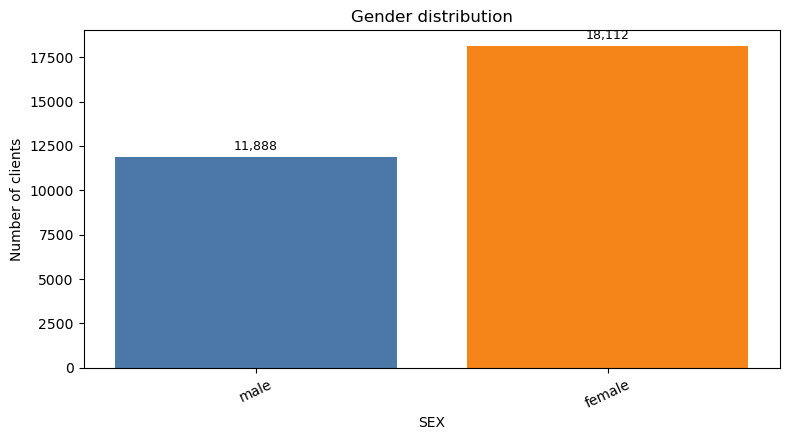

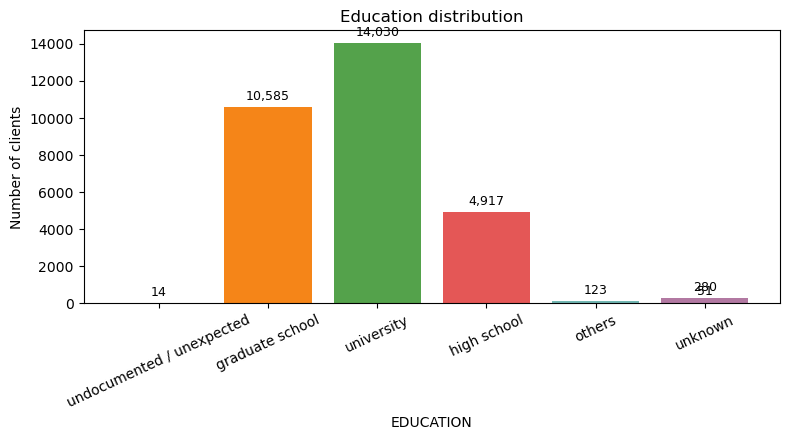

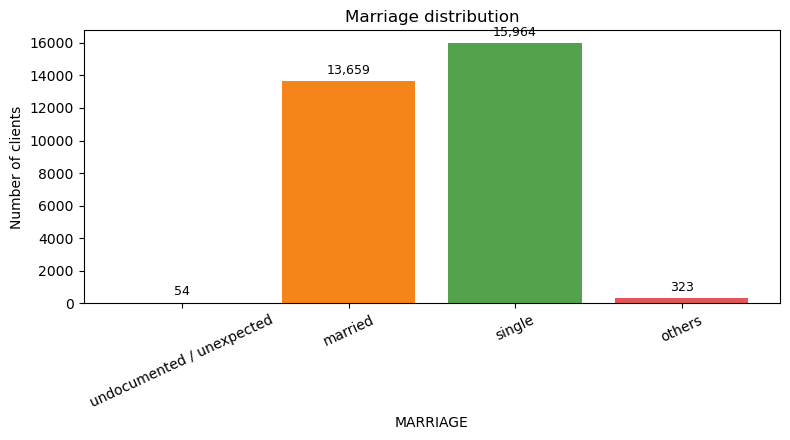

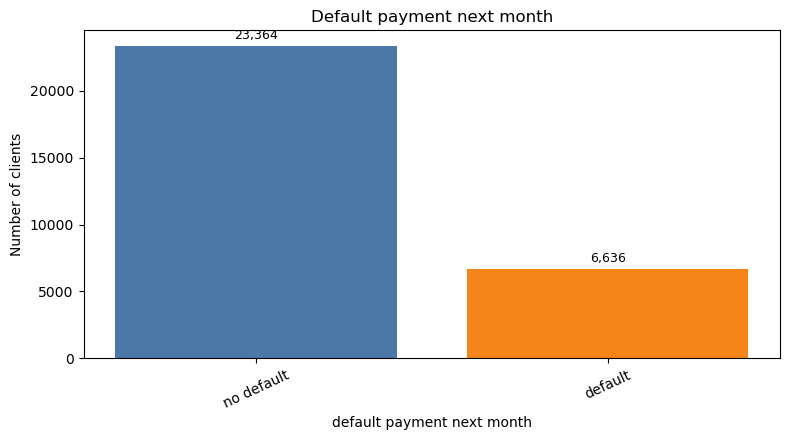

In [71]:
plot_labeled_counts("SEX", "Gender distribution")
plot_labeled_counts("EDUCATION", "Education distribution")
plot_labeled_counts("MARRIAGE", "Marriage distribution")
plot_labeled_counts("default payment next month", "Default payment next month")


### Repayment Status Count Plots

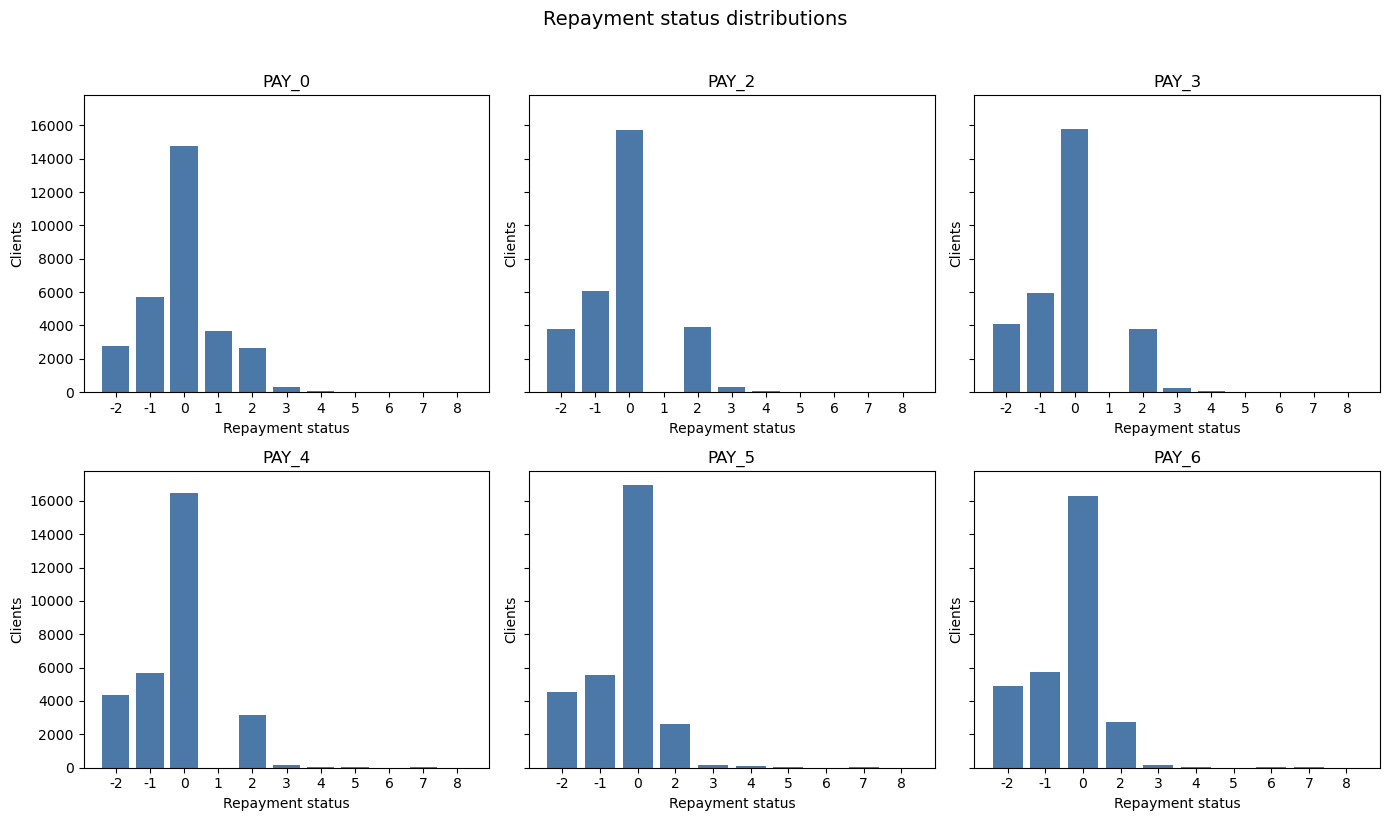

In [72]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.ravel()

for ax, column in zip(axes, pay_status_columns):
    counts = df[column].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="#4C78A8")
    ax.set_title(column)
    ax.set_xlabel("Repayment status")
    ax.set_ylabel("Clients")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Repayment status distributions", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


### Default Rate Plots

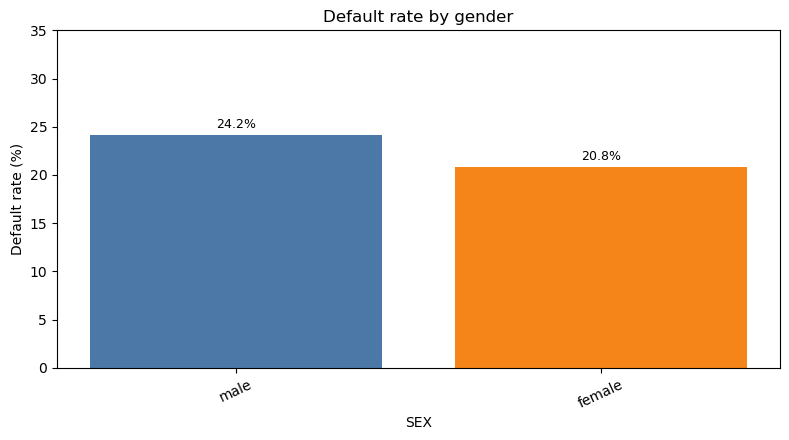

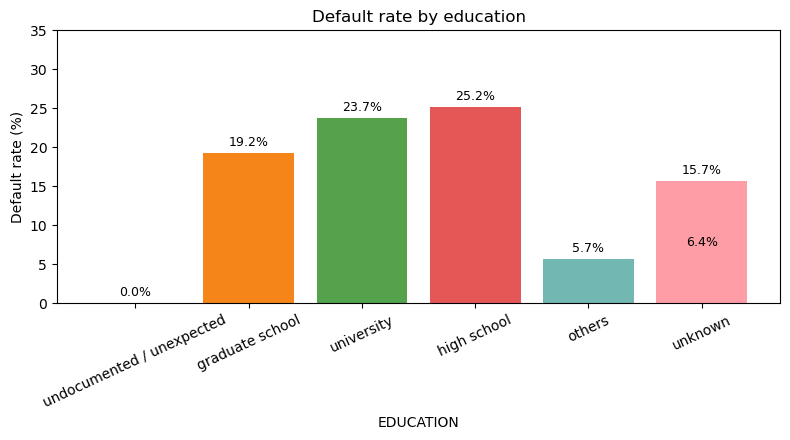

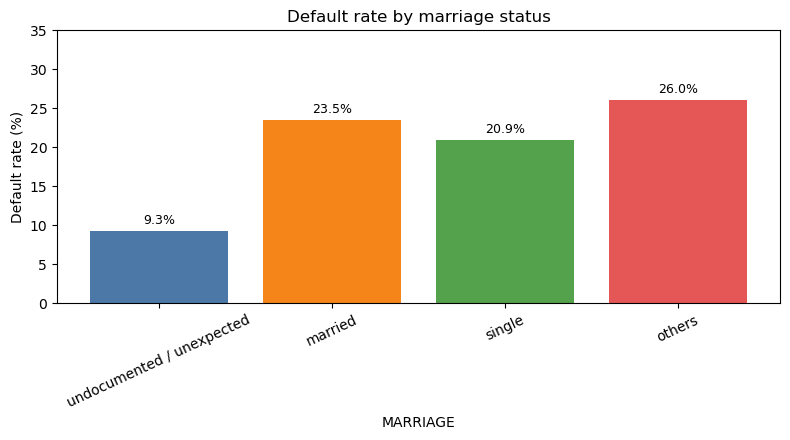

In [73]:
plot_default_rate("SEX", "Default rate by gender")
plot_default_rate("EDUCATION", "Default rate by education")
plot_default_rate("MARRIAGE", "Default rate by marriage status")


## Useful Numeric Plots

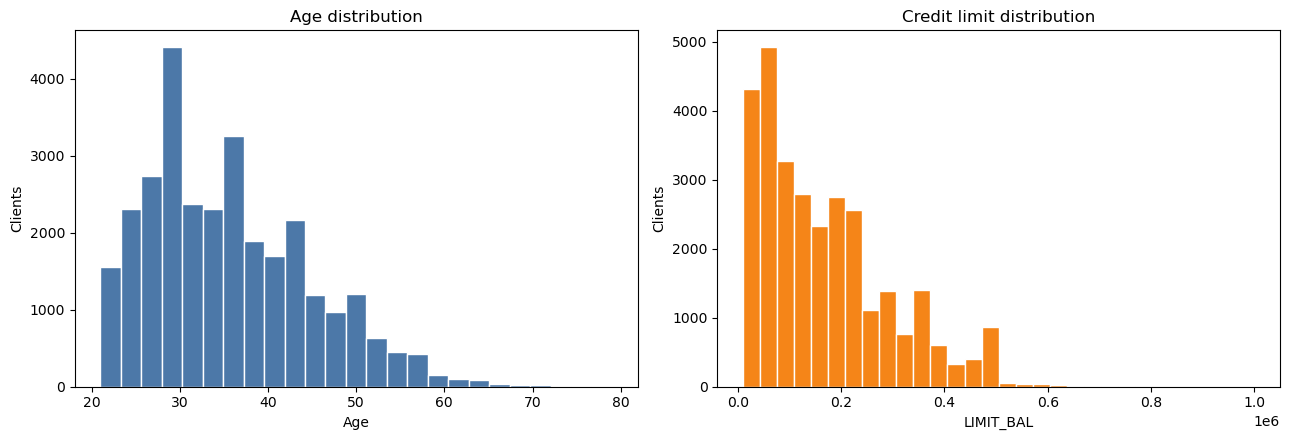

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["AGE"], bins=25, color="#4C78A8", edgecolor="white")
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Clients")

axes[1].hist(df["LIMIT_BAL"], bins=30, color="#F58518", edgecolor="white")
axes[1].set_title("Credit limit distribution")
axes[1].set_xlabel("LIMIT_BAL")
axes[1].set_ylabel("Clients")

fig.tight_layout()
plt.show()
